In [9]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sqlite3 

plt.rcParams['axes.grid'] = True
plt.rcParams['axes.facecolor'] = 'lightgrey'
plt.rcParams['grid.linestyle'] = '--'  
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.alpha'] = 0.8

FPARAMS = {'fontfamily': 'Arial'}  # ! constants
XLABELFPARAMS = {'fontfamily':'Arial', 'fontsize': 13, 'labelpad': 10, 'fontstyle': 'italic'}  # ! constants
YLABELFPARAMS = {'fontfamily':'Arial', 'fontsize': 13, 'labelpad': 10, 'fontstyle': 'italic'}  # ! constants

CATEG_COLORS = ["#1900FF", "#001D3A", "#74C0FF", "#7F04F1", "#615F5F"]  # ! constants

conn = sqlite3.connect('sentinel.db')
crs = conn.cursor()

### 1. Статистика продаж по месяцам за 2026 год 

,month_revenue
order_date,
January,1712224
February,1830331
March,2021594
April,1526316
May,1514635
June,1433187
July,1793415
August,2858437
September,3571179


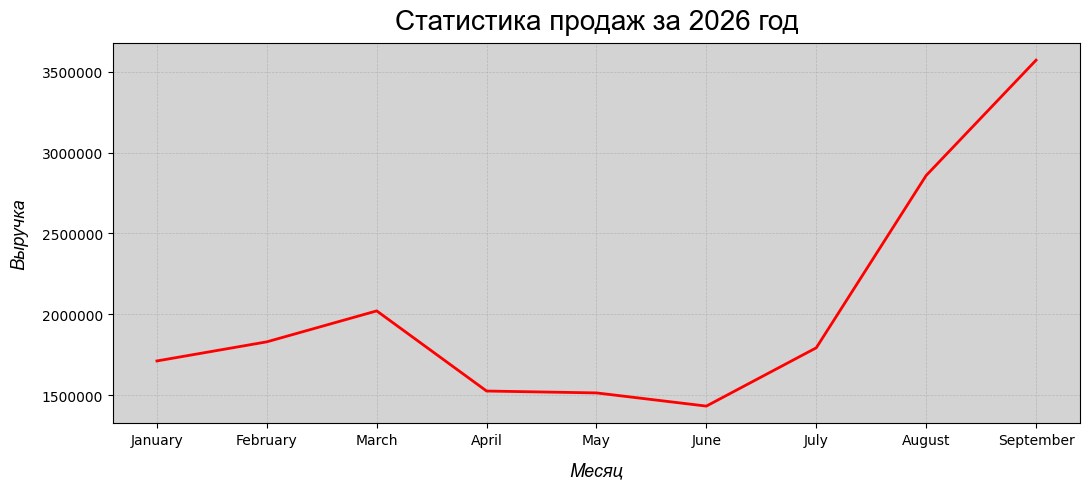

In [2]:
month_revenue_stats = pd.read_sql_query('''
SELECT o.order_date, SUM(oi.quantity * p.price) month_revenue 
FROM orders o JOIN order_items oi ON o.order_id = oi.order_id 
			  JOIN products p ON oi.product_id = p.product_id
WHERE o.status != 'cancelled'
GROUP BY SUBSTR(o.order_date, 1, 7)
ORDER BY o.order_date;                  
''', conn)

month_revenue_stats.order_date = pd.to_datetime(month_revenue_stats.order_date, format='%Y-%m-%d')
month_revenue_stats.order_date = month_revenue_stats.order_date.dt.month_name()
month_revenue_stats = month_revenue_stats.set_index('order_date')

display(month_revenue_stats)


fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
	month_revenue_stats.index, month_revenue_stats.month_revenue, 
	color='red', lw=2
)

ax.ticklabel_format(style='plain', axis='y')
ax.set_title('Статистика продаж за 2026 год', **FPARAMS, fontsize=20, pad=10)
ax.set_xlabel('Месяц', **XLABELFPARAMS)
ax.set_ylabel('Выручка', **YLABELFPARAMS)

plt.tight_layout()

##### **Вывод:** по графику можно отследить *нестабильность выручки* — падение с марта по июнь, потом — резкий рост с июля по сентябрь, пик в сентябре *(~3.6 млн)*. Четко прослеживается *сезонность* — весной и в конце лета спрос падает, а с конца лета начинается актиный рост. Это классический паттерн для рынка охранных систем: спрос растёт к концу года (подготовка к зиме, закрытие бюджетов). Рекомендуется усилить запасы и маркетинг к августу–сентябрю.

### 2. Статистика продаж по категориям 

,category_revenue
category_name,
Контроль доступа,8146435
Сигнализация,4926822
Видеонаблюдение,3702879
Питание и кабели,1247940
Освещение,237242


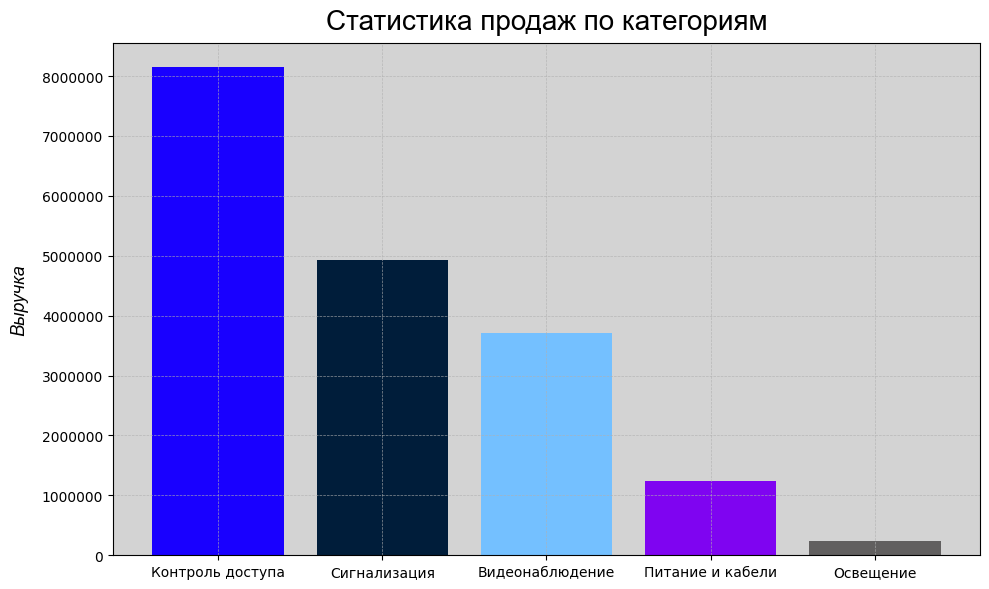

In [3]:
category_stats = pd.read_sql_query('''
SELECT c.category_name, SUM(p.price * oi.quantity) category_revenue
FROM categories c JOIN products p ON c.category_id = p.category_id
				  JOIN order_items oi ON p.product_id = oi.product_id
				  JOIN orders o ON oi.order_id = o.order_id
WHERE o.status != 'cancelled'
GROUP BY c.category_name
ORDER BY category_revenue DESC; 
''', conn)

category_stats = category_stats.set_index('category_name')
display(category_stats)


fix, ax = plt.subplots(figsize=(10, 6))

ax.bar(
	x=category_stats.index, height=category_stats.category_revenue,
	color = CATEG_COLORS
)

ax.ticklabel_format(style='plain', axis='y')
ax.set_title('Статистика продаж по категориям', **FPARAMS, fontsize=20, pad=10)
ax.set_ylabel('Выручка', **XLABELFPARAMS)

plt.tight_layout()

##### **Вывод:** на графике виден резкий разрыв между категориями. *Контроль доступа* — лидер с *~8.2M*, что почти в 2 раза больше второй категории (сигнализация). *Освещение* — аутсайдер (~0.3M), что примерно в 25 раз меньше лидера. Таким образом, *бизнес сильно зависит от одной категории*. 80% выручки дают 2 категории (контроль доступа + сигнализация). Категория "освещение" почти не продаётся — либо маленький ассортимент, либо низкий спрос. Стоит расширить ассортимент освещения / пересмотреть закупки — сейчас это убыточное направление.

### 3. Статистика продаж по магазинам 

,total_revenue
store_name,
"Sentinel Москва, Арбат",3302723
Sentinel Одинцово,3295490
Sentinel Мытищи,3263740
"Sentinel Москва, Тверская",2846674
Sentinel Химки,2798647
"Sentinel Москва, Сити",2754044


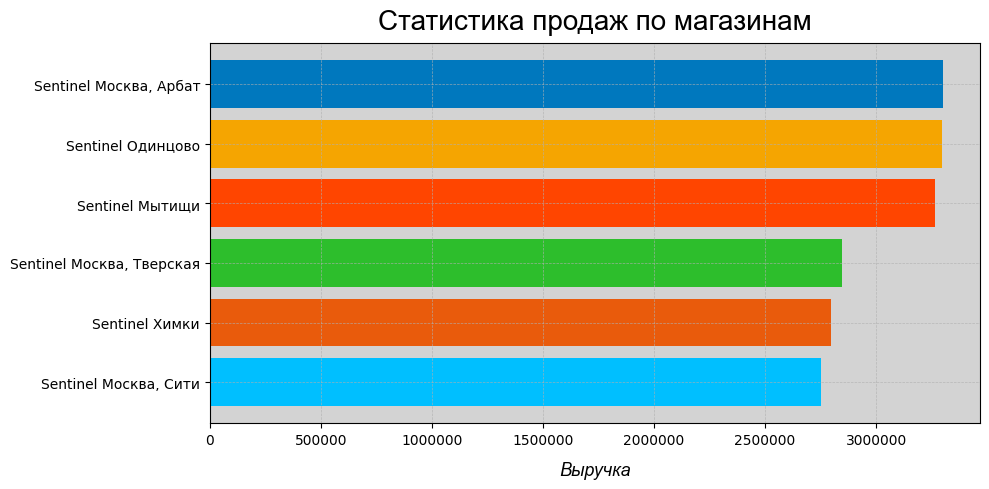

In [4]:
store_stats = pd.read_sql_query('''
SELECT 
	s.name store_name, 
	SUM(p.price * oi.quantity) total_revenue 
FROM stores s JOIN orders o ON s.store_id = o.store_id
			  JOIN order_items oi ON o.order_id = oi.order_id 
			  JOIN products p ON p.product_id = oi.product_id
WHERE o.status != 'cancelled'
GROUP BY s.name 
ORDER BY total_revenue DESC;                                
''', conn)

store_stats = store_stats.set_index('store_name')
display(store_stats)


fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
	y=store_stats.index[::-1], width=store_stats.total_revenue[::-1], 
	color=['#00BFFF', '#E95B0C', '#2DBE2C', "#FF4500", '#F5A501', '#0078BE']
)

ax.ticklabel_format(style='plain', axis='x')
ax.set_title('Статистика продаж по магазинам', **FPARAMS, fontsize=20, pad=10)
ax.set_xlabel('Выручка', **XLABELFPARAMS)

plt.tight_layout()

##### **Вывод:** на графике видно, что *выручка магазинов почти одинаковая* — она находится в диапазоне *[2.75 млн; 3.25 млн]*. Разрыв минимален и составляет *~15%*. Таким образом, все 6 магазинов работают примерно одинаково эффективно — *нет явных лидеров и отстающих*. Это хорошо с точки зрения стабильности сети, но плохо, потому что нет точки роста. 
> NB! Данные равномерные искусственно (распределение заказов случайное). Для реального анализа стоило бы учитывать географию, плотность клиентов и сезонность по каждому филиалу.

### 4. Топ-15 клиентов по общей сумме всех заказов 

,first_name,last_name,orders_qty,total_cheque,avg_cheque
customer_id,,,,,
33,Никита,Кудрявцев,11,390998,35545
28,Полина,Андреева,11,387004,35182
67,Антон,Ермаков,11,362092,32917
44,Василиса,Александрова,11,350515,31865
70,Аглая,Филиппова,10,346286,34628
34,Валерия,Баранов,10,345014,34501
68,Лилия,Антонова,11,344147,31286
50,Мия,Соболева,11,339888,30898
76,Камилла,Фомина,10,323534,32353


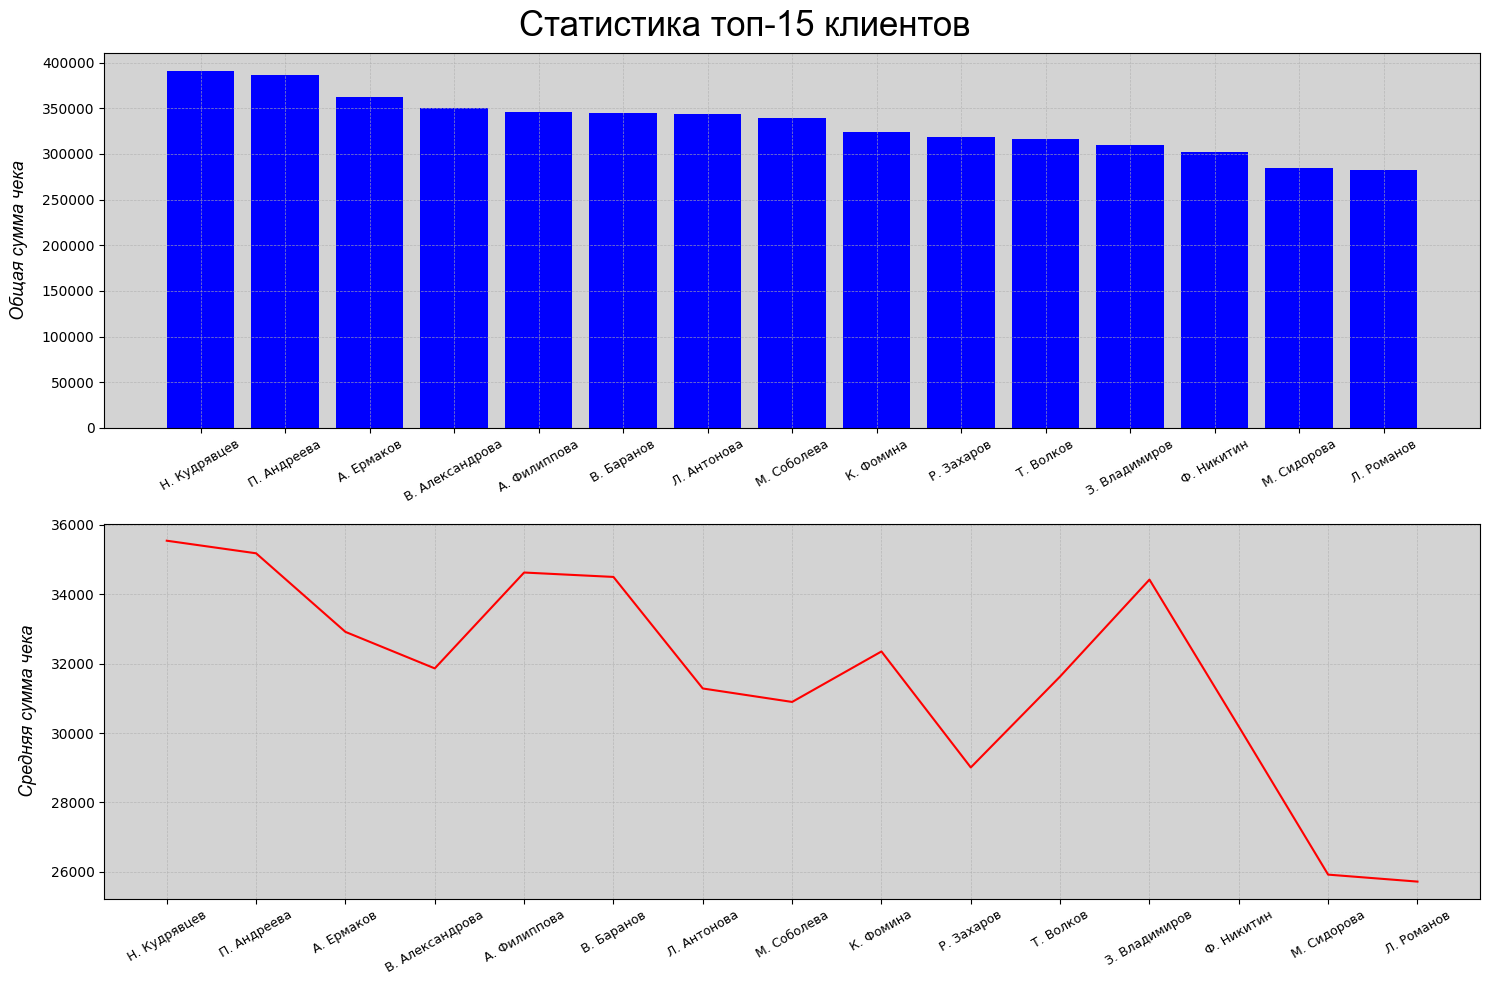

In [13]:
client_stats = pd.read_sql_query('''
SELECT 	
	c.customer_id, c.first_name, c.last_name, 
	COUNT(DISTINCT o.order_id) orders_qty, 
	SUM(p.price * oi.quantity) total_cheque, 
	SUM(p.price * oi.quantity) / COUNT(DISTINCT o.order_id) avg_cheque
FROM customers c JOIN orders o ON c.customer_id = o.customer_id
				 JOIN order_items oi ON o.order_id = oi.order_id
				 JOIN products p ON p.product_id = oi.product_id
WHERE o.status != 'cancelled'
GROUP BY c.customer_id, c.first_name, c.last_name
ORDER BY total_cheque DESC, orders_qty DESC 
LIMIT 15;                                  
''', conn)

client_stats = client_stats.set_index('customer_id')
display(client_stats)


fig, ax = plt.subplots(2, figsize=(15, 10))

xlabels = [f'{fn[0]}. {ln}' for fn, ln in zip(client_stats.first_name, client_stats.last_name)]

ax[0].bar(
	x=xlabels, height=client_stats.total_cheque, 
	color='blue'
)

ax[1].plot(
	xlabels, client_stats.avg_cheque, 
	color='red'
)

for subax in ax: 
	subax.set_xticks(range(len(xlabels)))
	subax.set_xticklabels(xlabels, rotation=30, fontsize=9)

plt.suptitle('Статистика топ-15 клиентов', **FPARAMS, y=.98, fontsize=25)
ax[0].set_ylabel('Общая сумма чека', **YLABELFPARAMS)
ax[1].set_ylabel('Средняя сумма чека', **YLABELFPARAMS)

plt.tight_layout()

##### **Вывод:** *по первому графику* видно, что *топ-15 клиентов близки по сумме* — от 285 тыс. до 390 тыс. Прослеживается плавное падение по рейтингу, без резких обрывов. *По второму графику* видно, что *средний чек сильно колеблется* — от 26 тыс. до 35 тыс. Например, у Н. Кудрявцева — высокий средний чек (~35 тыс.), у Л. Романова — низкий (~25 тыс.), хотя общая сумма у обоих похожа. На основании данных наблюдений можно понять, что среди топ-15 клиентов есть **разные типы:** 
- *«крупные разовые»* — высокий средний чек, мало заказов (например, Н. Кудрявцев),
- *«частые мелкие»* — низкий средний чек, много заказов (Л. Романов).
##### Первых стоит удерживать через VIP-программы, вторых — стимулировать к более крупным покупкам (апсейл, комплекты). Стратегия не может быть одинаковой для всех топ-клиентов.

### 5. Успешность продаж по месяцам за 2026 год 

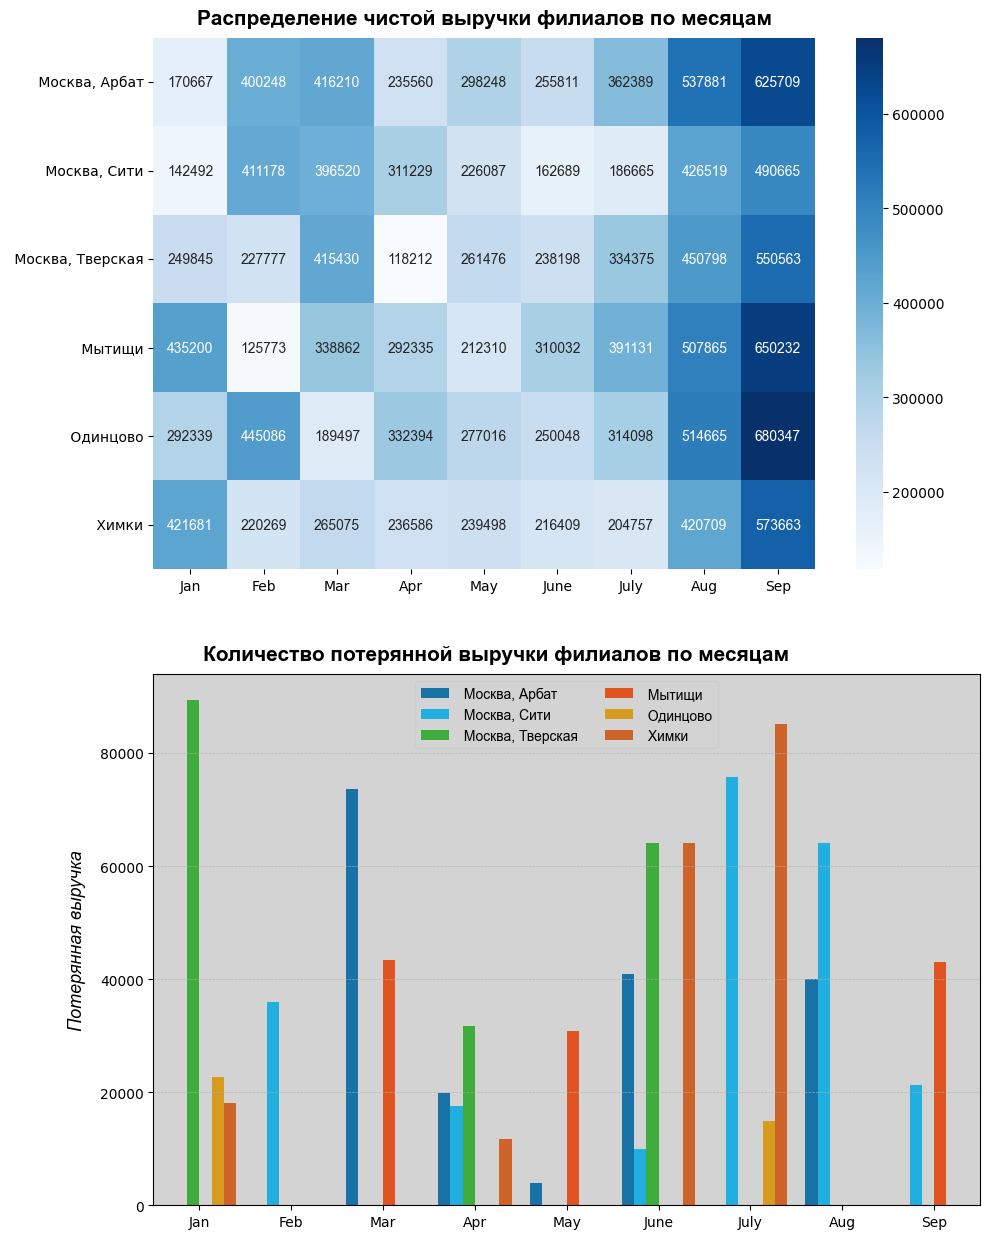

In [6]:
selling_stats = pd.read_sql_query('''
SELECT 
	order_date order_month, 
	s.name store_name, 
	COUNT(DISTINCT CASE WHEN o.status = 'cancelled' THEN o.order_id END) AS cancelled_orders_qty,
	COUNT(DISTINCT CASE WHEN o.status != 'cancelled' THEN o.order_id END) AS successful_orders_qty,
	SUM(CASE WHEN o.status != 'cancelled' THEN p.price * oi.quantity ELSE 0 END) clear_revenue, 
	SUM(CASE WHEN o.status = 'cancelled' THEN p.price * oi.quantity ELSE 0 END) lost_revenue
FROM orders o JOIN stores s ON o.store_id = s.store_id
			  JOIN order_items oi ON o.order_id = oi.order_id
			  JOIN products p ON p.product_id = oi.product_id
GROUP BY SUBSTR(order_date, 1, 7), s.name  
ORDER BY SUBSTR(order_date, 1, 7), store_name, lost_revenue;                                   
''', conn)

selling_stats.order_month = pd.to_datetime(selling_stats.order_month, format='%Y-%m-%d')
selling_stats.order_month = selling_stats.order_month.dt.month_name()
selling_stats = selling_stats.set_index(['order_month', 'store_name'])


fig, ax = plt.subplots(2, figsize=(10, 12.5))

pivot_selling_stats = selling_stats.reset_index().pivot_table(
    index='store_name',
    columns='order_month', 
    values='clear_revenue', 
    sort=False
    )

sns.heatmap(
	data=pivot_selling_stats, ax=ax[0], 
	annot=True, fmt='.0f', annot_kws=FPARAMS, 
	cmap='Blues'
)

sns.barplot(
	data=selling_stats.reset_index(), x='order_month', y='lost_revenue', 
	hue='store_name', palette=['#0078BE', '#00BFFF', '#2DBE2C', "#FF4500", '#F5A501', '#E95B0C'], 
)

shortened_months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'July', 'Aug', 'Sep']

ax[0].grid(visible=False)
ax[0].set_xticklabels(shortened_months)
ax[0].set_yticklabels([n.strip('Sentinel') for n in selling_stats.index.get_level_values(1).unique()])
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].set_title('Распределение чистой выручки филиалов по месяцам', **FPARAMS, fontsize=15, pad=10, fontweight='semibold')

ax[1].set_xticks(selling_stats.index.get_level_values(0).unique())
ax[1].set_xticklabels(shortened_months)
ax[1].set_xlabel('')
ax[1].set_ylabel('Потерянная выручка', **YLABELFPARAMS)
ax[1].set_title('Количество потерянной выручки филиалов по месяцам', **FPARAMS, fontsize=15, pad=10, fontweight='semibold', x=0.415)

handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend(
    handles=handles, labels=[l.strip('Sentinel') for l in labels], 
    ncols=2, prop={'family': 'Arial'}
    )

fig.subplots_adjust(hspace=130)

plt.tight_layout()

##### **Вывод:** *по первому графику* видно, что *выручка сильно различается по месяцам и магазинам*. Сентябрь — пиковый у всех магазинов (500 тыс.–680 тыс.). Апрель — провал у большинства. *По второму графику* видно, что *выручка с отмененных заказов сильно разнится* — от почти нуля до 88 тыс. Филиал "Москва-Тверская" — лидер по потерям (~88 тыс. в январе), а у филиалов в Мытищах и Химках стабильно высокие потери. В мае — минимум отмен у всех. Таким образом, *отмены являются существенной проблемой*. За 9 месяцев потери составляют *~10–15%* от чистой выручки. Пики отмен коррелируют с пиками выручки (январь, июль, сентябрь) — возможно, перегрузка в горячие месяцы. Также видна разница между филиалами: одни теряют в 5 раз больше других при сопоставимой выручке — значит, проблема в процессах, а не в спросе. Рекомендуется изучить причины отмен в Тверской, Мытищах, Химках — там потери максимальны.

### 6. ABC-анализ товаров 

,revenue,cum_share,abc_class
product_name,,,
Входные двери повышенной защиты,3147760,0.164,A
Умная сигнализация с модулем GSM-связи,2969835,0.319,A
Электронный сейф с кодовым замком,2244678,0.436,A
Турникет трёхрожковый,1650000,0.522,A
IP-камера наружного наблюдения,1637818,0.607,A
Датчик движения для помещений,1583856,0.690,A
Профессиональный Wi-Fi видеодомофон,1402077,0.763,A
Система контроля доступа с картами,482050,0.788,A
Многофункциональный видеорегистратор,451770,0.812,B


,a_class_qty,b_class_qty,c_class_qty,total_qty,a_class_share
category_name,,,,,
Контроль доступа,4,2,5,11,0.36
Сигнализация,2,1,6,9,0.22
Видеонаблюдение,2,2,1,5,0.40
Питание и кабели,0,4,2,6,0.00
Освещение,0,1,1,2,0.00


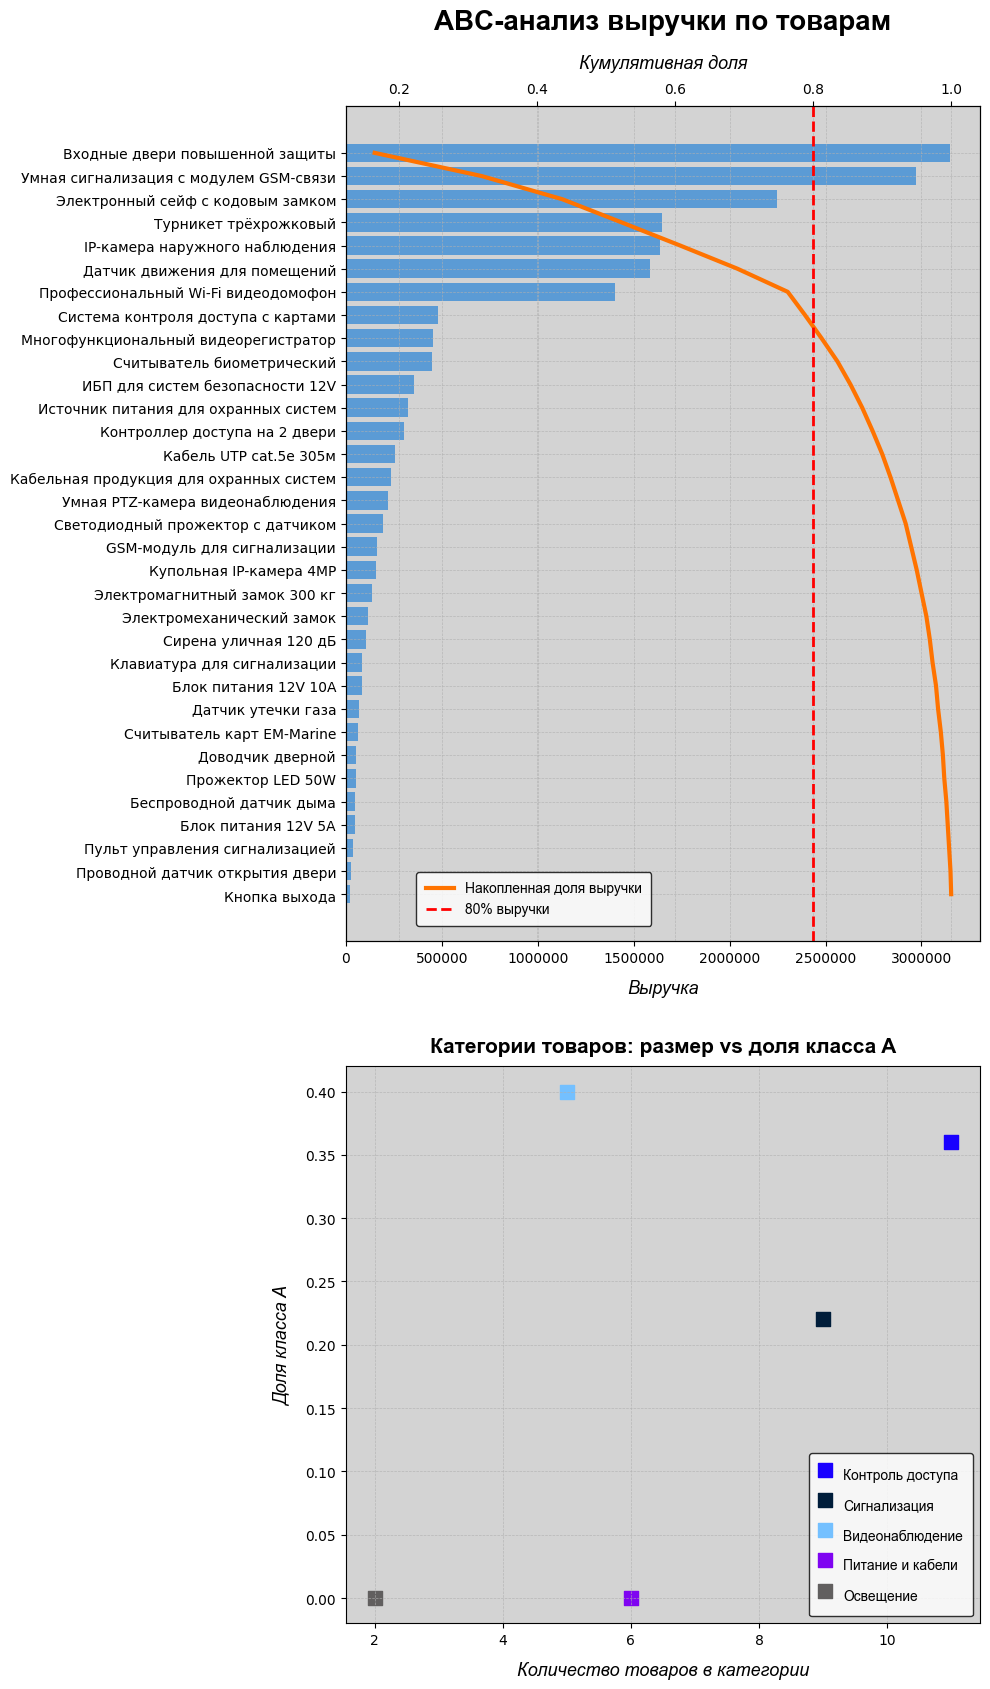

In [7]:
crs.executescript('''
    CREATE TEMP TABLE IF NOT EXISTS abc_result AS 
	WITH cte AS (
		SELECT c.category_name, p.name product_name, SUM(p.price * oi.quantity) revenue 
		FROM products p JOIN order_items oi ON p.product_id = oi.product_id
						JOIN categories c ON p.category_id = c.category_id 
		GROUP BY p.product_id, p.name
	), cte2 AS (
		SELECT 
			category_name, product_name, revenue,
			SUM(revenue) OVER(ORDER BY revenue DESC, product_name) * 1.0 / SUM(revenue) OVER() cum_share 
		FROM cte
	)
	SELECT 
		category_name, product_name, revenue, ROUND(cum_share, 3) cum_share, 
		CASE 
			WHEN cum_share <= .8 THEN 'A'
			WHEN cum_share <= .95 THEN 'B' 
			ELSE 'C'
		END abc_class 
	FROM cte2;            
''')

abc_detailed = pd.read_sql_query('''
    SELECT product_name, revenue, cum_share, abc_class
    FROM abc_result
    ORDER BY revenue DESC, product_name;            
''', conn)

abc_categories = pd.read_sql_query('''
    SELECT 
        category_name, 
        SUM(CASE WHEN abc_class = 'A' THEN 1 ELSE 0 END) a_class_qty,
        SUM(CASE WHEN abc_class = 'B' THEN 1 ELSE 0 END) b_class_qty,
        SUM(CASE WHEN abc_class = 'C' THEN 1 ELSE 0 END) c_class_qty, 
        COUNT(*) total_qty, 
        ROUND(SUM(CASE WHEN abc_class = 'A' THEN 1.0 ELSE 0 END) / COUNT(*), 2) a_class_share
    FROM abc_result 
    GROUP BY category_name
    ORDER BY a_class_qty DESC; 
''', conn)

abc_detailed = abc_detailed.set_index('product_name')
abc_categories = abc_categories.set_index('category_name')

display(abc_detailed)
display(abc_categories)


fig, ax = plt.subplots(2, figsize=(10, 17), gridspec_kw={'height_ratios': [1.8, 1.2]})

ax[0].barh(
	y=abc_detailed.index[::-1], width=abc_detailed.revenue[::-1], 
	color='#5B9BD5'
)
ax[0].set_xlabel('Выручка', **XLABELFPARAMS)

ax2 = ax[0].twiny()
ax2.plot(
	abc_detailed.cum_share, abc_detailed.index, 
	color="#ff7300", lw=3, label='Накопленная доля выручки'
)
ax2.axvline(x=.8, lw=2, color='red', ls='--', label='80% выручки')
ax2.set_xlabel('Кумулятивная доля', **XLABELFPARAMS)

ax[0].ticklabel_format(style='plain', axis='x')

ax2.legend(
	loc='lower left', 
	bbox_to_anchor=(.1, .01), 
	prop={'family': 'Arial'}, 
	facecolor='white', edgecolor='black', 
	borderpad=.7
)

categ_colors = dict(zip(abc_categories.index, CATEG_COLORS))

for categ, row in abc_categories.iterrows():
	ax[1].scatter(
		x=row.total_qty, y=row.a_class_share, 
		color=categ_colors[categ], label=categ, 
		s=100, marker='s'
	)

ax[1].set_xlabel('Количество товаров в категории', **XLABELFPARAMS)
ax[1].set_ylabel('Доля класса A', **YLABELFPARAMS)

ax[1].legend(
	loc='lower right', 
	prop={'family': 'Arial'}, 
	facecolor='white', edgecolor='black', 
	borderpad=.7, 
	handlelength=1, handleheight=2.2
)

plt.subplots_adjust(hspace=7)
ax[0].set_title('ABC-анализ выручки по товарам', **FPARAMS, fontsize=20, pad=18, weight='semibold')
ax[1].set_title('Категории товаров: размер vs доля класса A', **FPARAMS, fontsize=15, pad=10, weight='semibold')
plt.tight_layout()

##### ***Вывод:*** 
- *класс А:* 8/33 товаров, 80% выручки. Топ-3 — входные двери, сигнализация с GSM и электронный сейф составляют 44%. Фактически бизнес держится на трёх позициях, что имеет высокий риск.
- *класс B:* 10/33 товаров, 15% выручки. Резерв, из которого можно получить новые лидирующие товары. Купольная IP-камера 4MP находится ровно на пороге 0.95. Это пограничный товар, и его стоит держать в поле зрения.
- *класс C:* 15/33 товаров, 5% выручки. Это 45% от всех товаров, что составляет почти половину ассортимента, которая практически не работает.

**Категории:** 
- *Видеонаблюдение* — 5 товаров, 40% в классе A. Это небольшая, но сильная категория с потенциалом роста.
- *Контроль доступа* — крупнейшая категория: 11 товаров, 4 в A и 5 в C. Есть сильное ядро, но нужно пересмотреть слабые позиции.
- *Сигнализация* — 9 товаров, из них 6 в C. Категория заметно проседает и требует анализа слабых позиций.
- *Питание и кабели* — 6 товаров, преимущественно B (4 позиции). Стабильная вспомогательная категория без товаров A.
- *Освещение* — всего 2 товара, поэтому делать выводы о категории рано.

**Следовательно,** стоит удерживать позиции A, развивать B, сокращать C и снижать зависимость от топ-3 товаров.

### 7. RFM-анализ клиентов 

In [10]:
client_stats

,,orders_qty,total_cheque,avg_cheque
first_name,last_name,,,
Никита,Кудрявцев,11,390998,35545
Полина,Андреева,11,387004,35182
Антон,Ермаков,11,362092,32917
Василиса,Александрова,11,350515,31865
Аглая,Филиппова,10,346286,34628
Валерия,Баранов,10,345014,34501
Лилия,Антонова,11,344147,31286
Мия,Соболева,11,339888,30898
Камилла,Фомина,10,323534,32353


In [ ]:
# conn.close()